# E-Commerce Product Recommender
**Step 1: Problem Framing**

## Problem Statement
Recommend products to users based on their past purchase behavior, to help drive cross-sell and repeat purchases.

- **Task type:** Recommendation system
- **Approach:** Item-based collaborative filtering (products bought by similar users), compared against a content-based baseline (similar category/price)
- **Success metric:** Precision@5 - of the top 5 recommended products, how many did the user go on to actually buy
- **Business KPI:** Increased cross-sell rate / average order value

### Why a recommender, and not forecasting or clustering?
Demand forecasting predicts *how much* of a product sells in aggregate, but it doesn't say what to show a specific customer. Clustering groups similar customers but still leaves "what do we recommend" unanswered. A recommender directly targets the business goal: surface the right products to the right person.

This is only feasible because of a repeat-purchase check (see Step 2 below): **88% of the 2,890 users have 2+ orders**, giving collaborative filtering enough purchase history to find "customers like you also bought..." patterns. Without repeat purchases, there'd be no history to recommend from.

### Why Precision@5, not RMSE/accuracy?
This is a ranking problem, not regression or classification, so there's no single correct number to predict. Precision@5 mirrors how the recommendation would actually be deployed (a "recommended for you" widget showing ~5 products) and answers the practical question directly: of the 5 products shown, how many did the customer go on to buy?

### Tying the metric to the KPI
Higher Precision@5 means more of the recommended slots are products the customer actually wants, which means more of those recommendations convert into add-on purchases, which raises cross-sell rate and average order value. Low Precision@5 means the widget is showing noise and isn't moving the business metric.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ecommerce_orders_10k_updated.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()


,order_id,user_id,product_id,category,price,qty,total_price,order_date,country,customer_segment
0,100000,861,201,Sports,93.11,2,186.22,2024-10-30 16:07:37,Brazil,Mid-Value
1,100001,1295,366,Home,101.09,1,101.09,2022-04-17 09:31:40,Canada,Low-Value
2,100002,1131,115,Electronics,253.61,1,253.61,2022-11-08 12:38:20,India,Mid-Value
3,100003,1096,159,Clothing,11.73,2,23.46,2022-05-18 17:24:55,India,Low-Value
4,100004,1639,42,Electronics,743.98,2,1487.96,2024-01-25 05:51:54,Canada,High-Value


## Step 2: Data Understanding

**Source:** Kaggle - E-Commerce Orders Dataset (10K synthetic transactions), licensed CC BY 4.0. Full original data dictionary in `data/dataset_source_readme.md`.


In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate order_ids:", df.order_id.duplicated().sum())
print("\nUnique users:", df.user_id.nunique())
print("Unique products:", df.product_id.nunique())
print("Date range:", df.order_date.min(), "to", df.order_date.max())
df.describe()


Shape: (10000, 10)

Missing values:
 order_id            0
user_id             0
product_id          0
category            0
price               0
qty                 0
total_price         0
order_date          0
country             0
customer_segment    0
dtype: int64

Duplicate rows: 0
Duplicate order_ids: 0

Unique users: 2890
Unique products: 500
Date range: 2022-01-01 03:49:01 to 2025-08-11 22:21:28


,order_id,user_id,product_id,price,qty,total_price,order_date
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
mean,104999.50000,1502.626900,249.510700,103.141911,1.550400,159.583117,2023-10-17 07:11:47.309300
min,100000.00000,1.000000,1.000000,1.370000,1.000000,1.380000,2022-01-01 03:49:01
25%,102499.75000,762.750000,124.000000,25.350000,1.000000,31.477500,2022-11-23 04:21:51
50%,104999.50000,1493.000000,252.000000,55.375000,1.000000,74.200000,2023-10-11 16:00:45
75%,107499.25000,2250.250000,373.000000,128.285000,2.000000,182.682500,2024-09-12 05:24:06.250000
max,109999.00000,3000.000000,500.000000,901.730000,5.000000,3487.850000,2025-08-11 22:21:28
std,2886.89568,865.021722,144.079787,123.602789,1.012404,249.380101,NaN


### Data Dictionary
| Column | Description |
|---|---|
| order_id | Unique transaction ID |
| user_id | Unique customer ID |
| product_id | Unique product ID |
| category | Product category |
| price | Unit price (USD) |
| qty | Quantity purchased |
| total_price | price × qty |
| order_date | Timestamp of order |
| country | Customer's country |
| customer_segment | Low/Mid/High-Value, based on total purchase value |


### Data Quality
No missing values in any column, no duplicate rows, and no duplicate `order_id`s, so the dataset is clean going in. No negative or zero prices/quantities either (min price $1.37, min qty 1), so there are no obvious data-entry errors.

**Important caveat found later (Step 4c):** `product_id` does not map to a stable real-world product. The same `product_id` shows up under an average of 7.3 different categories (out of 8 possible) with very different prices each time. It behaves like a recycled slot number rather than a fixed catalog SKU. This doesn't affect the checks below, but it matters a lot for any model that assumes `product_id` has a fixed category/price (see Step 4c and the Limitations discussion in Step 5).

### Outliers
Applying the IQR rule to the numeric columns:


In [3]:
for col in ['price', 'qty', 'total_price']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col}: IQR bounds [{lo:.2f}, {hi:.2f}] -> {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


price: IQR bounds [-129.05, 282.69] -> 884 outliers (8.8%)
qty: IQR bounds [-0.50, 3.50] -> 703 outliers (7.0%)
total_price: IQR bounds [-195.33, 409.49] -> 937 outliers (9.4%)


`price`, `qty`, and `total_price` each have roughly 7-9% of rows flagged as outliers by the IQR rule, driven by right-skewed distributions (e.g. median price $55 vs. a max of $902). These read as genuine bulk/premium purchases rather than data errors (no negatives, no impossible values), so we keep them in the data. The recommender itself only uses binary "did this user buy this product," so price/qty skew doesn't affect it directly, but it's worth flagging for anyone later building a price-aware model.

### Distributions: country & customer segment


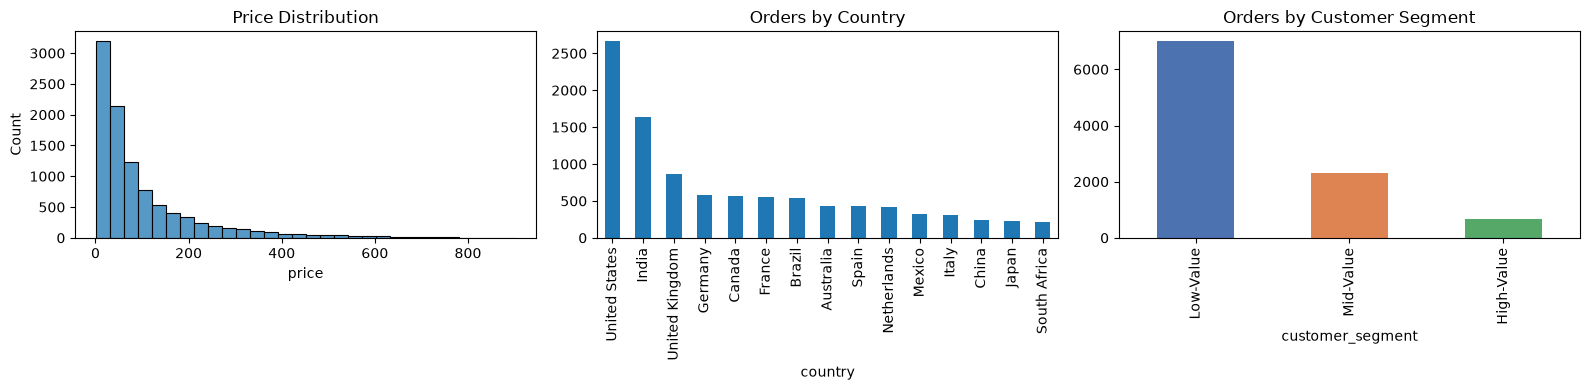

customer_segment
Low-Value     70.0
Mid-Value     23.1
High-Value     6.8
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['price'], bins=30, ax=axes[0])
axes[0].set_title('Price Distribution')

df['country'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Orders by Country')

df['customer_segment'].value_counts().plot(kind='bar', ax=axes[2], color=['#4c72b0', '#dd8452', '#55a868'])
axes[2].set_title('Orders by Customer Segment')

plt.tight_layout()
plt.show()

print(df['customer_segment'].value_counts(normalize=True).mul(100).round(1))


Both are heavily imbalanced: the US and India alone account for ~43% of all orders across 15 countries, and **70% of orders come from Low-Value customers**, with only 6.8% from High-Value customers. This isn't a data quality issue, but it does mean the smaller groups (e.g. South Africa, Japan, China, or the High-Value segment) have much less purchase history for the recommender to learn from - flagged here for the Step 5 fairness analysis.


## Step 3: Applied EDA

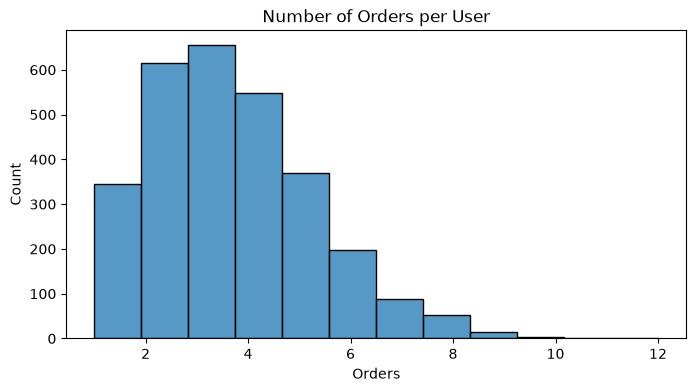

Users with 2+ orders (needed for recommendations): 2546


In [5]:
# Orders per user distribution
orders_per_user = df.groupby('user_id').size()
plt.figure(figsize=(8,4))
sns.histplot(orders_per_user, bins=12)
plt.title('Number of Orders per User')
plt.xlabel('Orders')
plt.show()

print("Users with 2+ orders (needed for recommendations):", (orders_per_user >= 2).sum())


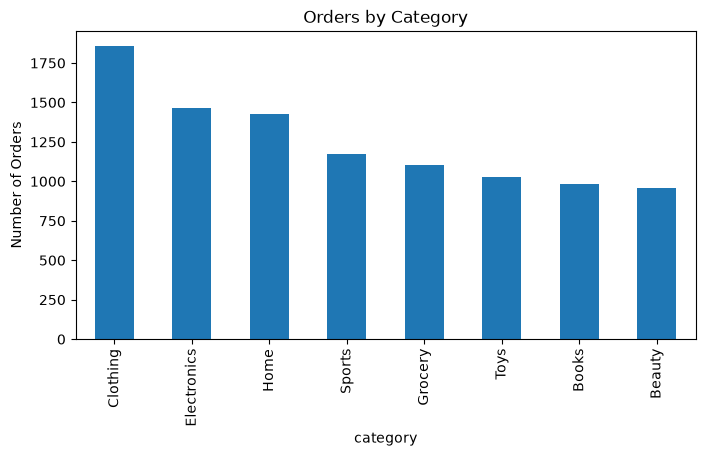

In [6]:
# Category popularity
plt.figure(figsize=(8,4))
df['category'].value_counts().plot(kind='bar')
plt.title('Orders by Category')
plt.ylabel('Number of Orders')
plt.show()


In [7]:
# Which categories are commonly bought together by the same user
category_by_user = df.groupby('user_id')['category'].apply(lambda x: set(x))
multi_category_users = category_by_user[category_by_user.apply(len) > 1]
print(f"{len(multi_category_users)} users bought from more than one category")


2450 users bought from more than one category


## Step 3b: Feature Engineering, Selection & Dimensionality Reduction

The collaborative-filtering recommender above only needs the raw binary purchase matrix, and doesn't use engineered features directly. But understanding customer behavior (and demonstrating feature selection / dimensionality reduction) calls for a richer **per-user profile**, built from the raw transactions:

- **Behavioral features:** number of orders, total spend, average order value, average quantity per order, number of distinct categories bought from, tenure (days between first and last order), recency (days since last order)
- **Category-spend profile:** what share of each user's total spend went to each of the 8 categories (a compositional "spending fingerprint" per user)

This profile isn't fed into the collaborative filtering recommender itself, but is useful for customer segmentation, a future hybrid/content-based model, and gives us a genuine feature matrix to apply feature selection and PCA to.


In [8]:
ref_date = df['order_date'].max()

user_features = df.groupby('user_id').agg(
    num_orders=('order_id', 'count'),
    total_spent=('total_price', 'sum'),
    avg_order_value=('total_price', 'mean'),
    avg_qty=('qty', 'mean'),
    num_categories=('category', 'nunique'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
).reset_index()

user_features['tenure_days'] = (user_features['last_order'] - user_features['first_order']).dt.days
user_features['recency_days'] = (ref_date - user_features['last_order']).dt.days
user_features = user_features.drop(columns=['first_order', 'last_order'])

# Category-spend profile: share of each user's total spend per category
cat_spend = df.pivot_table(index='user_id', columns='category', values='total_price', aggfunc='sum', fill_value=0)
cat_share = cat_spend.div(cat_spend.sum(axis=1), axis=0)
cat_share.columns = [f'cat_share_{c.lower()}' for c in cat_share.columns]

user_features = user_features.merge(cat_share.reset_index(), on='user_id')
print("User feature matrix shape:", user_features.shape)
user_features.describe().T


User feature matrix shape: (2890, 16)


,count,mean,std,min,25%,50%,75%,max
user_id,2890.0,1500.772318,864.526044,1.00,754.2500,1496.50000,2247.750000,3000.00
num_orders,2890.0,3.460208,1.749838,1.00,2.0000,3.00000,5.000000,12.00
total_spent,2890.0,552.190716,532.485930,2.81,184.9175,394.76500,754.007500,4697.16
avg_order_value,2890.0,161.393440,158.266181,2.81,66.7295,118.62375,199.763500,1992.84
avg_qty,2890.0,1.552460,0.623661,1.00,1.0000,1.40000,2.000000,5.00
num_categories,2890.0,2.806228,1.246593,1.00,2.0000,3.00000,4.000000,8.00
tenure_days,2890.0,622.129412,382.910535,0.00,307.2500,667.50000,941.000000,1317.00
recency_days,2890.0,349.301384,303.815776,0.00,106.2500,258.50000,517.750000,1318.00
cat_share_beauty,2890.0,0.070089,0.180421,0.00,0.0000,0.00000,0.035039,1.00
cat_share_books,2890.0,0.047134,0.146440,0.00,0.0000,0.00000,0.018658,1.00


### Feature Selection (Filter Method)

Correlation is scale-invariant, so it's a fair way to check for redundancy even though these 14 features live on very different scales (e.g. `total_spent` in dollars vs. `cat_share_*` as a 0–1 proportion). We check all pairwise correlations among the engineered features and flag anything strongly redundant.

This is a **filter method**: features are selected/dropped based on a statistical measure (correlation) computed directly on the data, independent of any model. This is different from a *wrapper* method (which would use a model's performance to decide, e.g. Recursive Feature Elimination) or an *embedded* method (where selection happens inside model training, e.g. Lasso).


In [9]:
feature_cols = [c for c in user_features.columns if c != 'user_id']
corr = user_features[feature_cols].corr()

high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.8:
            high_corr_pairs.append((feature_cols[i], feature_cols[j], round(c, 3)))

print("Highly correlated pairs (|r| > 0.8):")
for pair in high_corr_pairs:
    print(pair)


Highly correlated pairs (|r| > 0.8):
('num_orders', 'num_categories', np.float64(0.869))


`num_orders` and `num_categories` are correlated (r ≈ 0.87): the more orders a user places, the more chances they've had to buy from a new category. Between the two, we drop **`num_orders`** and keep `num_categories`: it more directly captures what actually matters for the cross-sell KPI (are customers spreading purchases across categories), so it's the more business-relevant of the two, and dropping its redundant twin reduces multicollinearity going into PCA.


In [10]:
selected_features = [c for c in feature_cols if c != 'num_orders']
print(f"Kept {len(selected_features)} of {len(feature_cols)} features:", selected_features)


Kept 14 of 15 features: ['total_spent', 'avg_order_value', 'avg_qty', 'num_categories', 'tenure_days', 'recency_days', 'cat_share_beauty', 'cat_share_books', 'cat_share_clothing', 'cat_share_electronics', 'cat_share_grocery', 'cat_share_home', 'cat_share_sports', 'cat_share_toys']


### Dimensionality Reduction - PCA

The remaining 14 features are on very different scales (`total_spent` has variance in the hundreds of thousands; `cat_share_books` has variance around 0.02). PCA is scale-sensitive, so without standardizing first, the high-scale dollar/day features would dominate the components regardless of whether they're actually the most informative axes of variation. So we standardize (zero mean, unit variance) before fitting PCA.


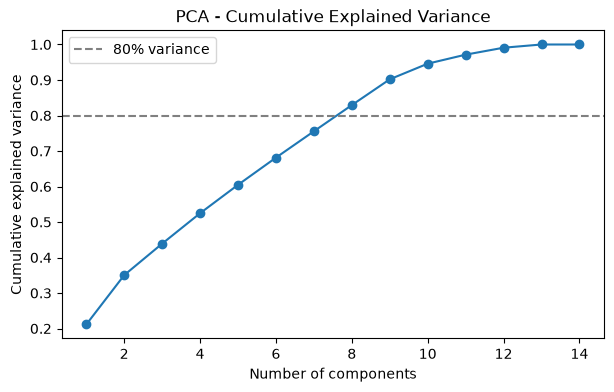

Components needed for 80% variance: 8 (of 14)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = user_features[selected_features].values
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA(n_components=len(selected_features)).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.8, color='gray', linestyle='--', label='80% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.show()

n_for_80 = int(np.argmax(cum_var >= 0.8) + 1)
print(f"Components needed for 80% variance: {n_for_80} (of {len(selected_features)})")


It takes 8 of the 14 components to reach 80% of the variance, so there isn't a lot of extreme redundancy left after the feature-selection step, which makes sense since most of these features describe genuinely different aspects of behavior (spend, timing, category mix). Still, the first 2 components are useful for visualization: they capture the two dominant axes of customer variation, so we can plot every user in 2D and color by customer segment to see whether the segments separate out spatially.


PC1 + PC2 explain 35.0% of variance


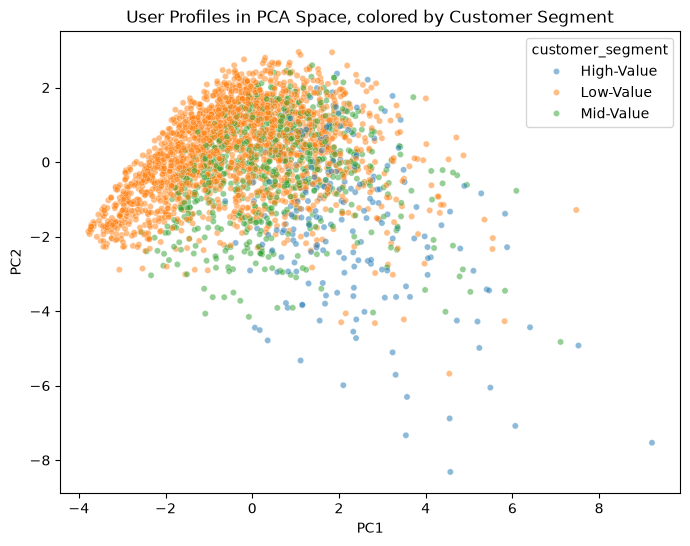


Top PC1 loadings:
total_spent              0.514880
avg_order_value          0.409013
cat_share_electronics    0.391729
tenure_days              0.323569
num_categories           0.318680
Name: PC1, dtype: float64

Top PC2 loadings:
tenure_days              0.506008
recency_days             0.459058
num_categories           0.433999
avg_order_value          0.427851
cat_share_electronics    0.266070
Name: PC2, dtype: float64


In [12]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"PC1 + PC2 explain {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance")

plot_df = user_features[['user_id']].copy()
plot_df['pc1'] = X_pca[:, 0]
plot_df['pc2'] = X_pca[:, 1]
plot_df = plot_df.merge(df[['user_id', 'customer_segment']].drop_duplicates('user_id'), on='user_id')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='customer_segment', alpha=0.5, s=20)
plt.title('User Profiles in PCA Space, colored by Customer Segment')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

loadings = pd.DataFrame(pca_2d.components_.T, index=selected_features, columns=['PC1', 'PC2'])
print("\nTop PC1 loadings:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop PC2 loadings:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))


PC1 is dominated by spend-related features (`total_spent`, `avg_order_value`) plus `cat_share_electronics` and `tenure_days`: essentially a "big spender / long tenure" axis. PC2 is dominated by `tenure_days` and `recency_days` in opposite directions: a "long-time but currently inactive" vs. "newer but recently active" axis. Segments overlap substantially in this 2D view rather than forming clean separate clusters, since `customer_segment` is defined by total purchase value alone while PCA is summarizing many behavioral dimensions at once. That's a reminder that 2 components (35% of variance) is a simplification useful for visualization, not a full substitute for the 9-component representation above.


### Feature Importance & Explainability (Model-Based)

The recommender itself doesn't have a natural target to explain (it's similarity-based, not predicting a label), so SHAP/LIME don't have anywhere to attach. But the data does have a real label we haven't used yet: `customer_segment`. Training a classifier to predict it from our engineered features, then reading off **model-based feature importances**, answers a genuinely useful business question: *which behaviors actually distinguish High-Value customers from Low-Value ones?*


Accuracy: 0.683

              precision    recall  f1-score   support

  High-Value       0.41      0.51      0.45        43
   Low-Value       0.83      0.75      0.79       399
   Mid-Value       0.45      0.54      0.49       136

    accuracy                           0.68       578
   macro avg       0.56      0.60      0.58       578
weighted avg       0.71      0.68      0.69       578



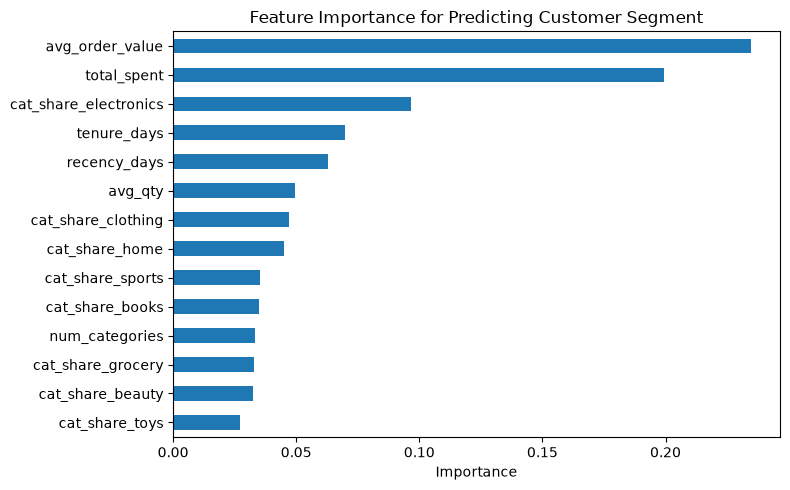

avg_order_value          0.234767
total_spent              0.199327
cat_share_electronics    0.096488
tenure_days              0.069695
recency_days             0.062898
avg_qty                  0.049373
cat_share_clothing       0.047267
cat_share_home           0.044966
cat_share_sports         0.035185
cat_share_books          0.034759
num_categories           0.033138
cat_share_grocery        0.032697
cat_share_beauty         0.032401
cat_share_toys           0.027039
dtype: float64

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

user_features_labeled = user_features.merge(
    df[['user_id', 'customer_segment']].drop_duplicates('user_id'), on='user_id'
)

X_clf = user_features_labeled[selected_features]
y_clf = user_features_labeled['customer_segment']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# class_weight='balanced' because segments are heavily imbalanced (70% Low-Value, Step 2)
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print()
print(classification_report(y_test, pred))

importances = pd.Series(clf.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance for Predicting Customer Segment')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


The classifier reaches **68% accuracy** (vs. a 70% "always guess Low-Value" baseline on raw accuracy, but note we used `class_weight='balanced'` so it isn't just defaulting to the majority class - the per-class report shows it's genuinely distinguishing all three segments, just imperfectly on the smaller High/Mid-Value groups).

**`avg_order_value` and `total_spent` are by far the top two features** - this is expected and a good sanity check, since the data dictionary defines `customer_segment` directly from total purchase value (Step 2). The more interesting finding is what shows up *after* those two: **`cat_share_electronics`** is the third most important feature, well ahead of tenure, recency, and the other category shares. That suggests customers who concentrate their spend in Electronics skew toward higher-value segments - a concrete, actionable signal for targeting or bundling, beyond the "big spenders are big spenders" tautology at the top.


## Step 4: Model Implementation - Collaborative Filtering

Approach: build a user-item purchase matrix, then recommend products
that similar users (by purchase pattern) have bought but this user hasn't.


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Build a user-item matrix (1 if user bought product, 0 otherwise)
user_item = pd.crosstab(df['user_id'], df['product_id'])
user_item = (user_item > 0).astype(int)
print("User-item matrix shape:", user_item.shape)
user_item.head()


User-item matrix shape: (2890, 500)


product_id,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
# Item-based similarity: which products tend to be bought by the same users
item_similarity = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_similarity, index=user_item.columns, columns=user_item.columns)
item_sim_df.head()


product_id,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
product_id,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000
2,0.0,1.000000,0.069007,0.0,0.0,0.0,0.0,0.097590,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.122628,0.0,0.0,0.000000
3,0.0,0.069007,1.000000,0.0,0.0,0.0,0.0,0.047140,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.06455,0.059235,0.0,0.0,0.000000
4,0.0,0.000000,0.000000,1.0,0.0,0.0,0.0,0.045644,0.051031,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.058926
5,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000


In [16]:
def recommend_products(user_id, n=5, user_item=user_item, item_sim_df=item_sim_df):
    """Recommend n products for a user based on items similar to what they've already bought.

    user_item/item_sim_df default to the full-data model (for live use), but can be
    swapped for a train-only version during evaluation to avoid leaking the held-out purchase.
    """
    if user_id not in user_item.index:
        return []
    bought = user_item.loc[user_id]
    bought_products = bought[bought > 0].index.tolist()

    scores = item_sim_df[bought_products].sum(axis=1)
    scores = scores.drop(labels=bought_products, errors='ignore')
    return scores.sort_values(ascending=False).head(n).index.tolist()

# Try it on a sample user
sample_user = user_item.index[0]
print(f"User {sample_user} previously bought:", user_item.loc[sample_user][user_item.loc[sample_user] > 0].index.tolist())
print(f"Recommended products:", recommend_products(sample_user))


User 1 previously bought: [453]
Recommended products: [95, 371, 230, 237, 448]


## Step 4b: Evaluation - Precision@5

Hold out each user's most recent purchase, then check whether our
recommender would have surfaced it.

**Avoiding leakage:** the similarity model must not be trained on the held-out
purchase, or the evaluation is meaningless (the item would either leak
information into the similarity scores, or, as in an earlier version of this
notebook, get excluded from the candidate list entirely because it's already
marked "bought," which forces Precision@5 to 0 by construction). So we rebuild
the user-item matrix from a training set that has the held-out purchases
removed, and evaluate against that.


In [17]:
df_sorted = df.sort_values('order_date')
last_purchase = df_sorted.groupby('user_id').tail(1)[['user_id', 'product_id']]

# Sample the test purchases, then hold them out of training entirely so the
# recommender can't see the answer it's being evaluated on.
test_sample = last_purchase.sample(min(300, len(last_purchase)), random_state=42)
train_df = df.drop(index=test_sample.index)

train_user_item = pd.crosstab(train_df['user_id'], train_df['product_id'])
train_user_item = (train_user_item > 0).astype(int)
train_item_sim_df = pd.DataFrame(
    cosine_similarity(train_user_item.T),
    index=train_user_item.columns, columns=train_user_item.columns
)

hits = 0
evaluated = 0
for _, row in test_sample.iterrows():
    recs = recommend_products(row['user_id'], n=5, user_item=train_user_item, item_sim_df=train_item_sim_df)
    if recs:
        evaluated += 1
        if row['product_id'] in recs:
            hits += 1

precision_at_5 = hits / evaluated if evaluated else 0
print(f"Evaluated on {evaluated} users")
print(f"Precision@5: {precision_at_5:.3f}")


Evaluated on 266 users
Precision@5: 0.011


## Step 4c: Content-Based Baseline

As a comparison model, build a recommender based on item *content* (category + price) instead of co-purchase behavior: recommend products whose category/price profile resembles what the user has already bought.

**Caveat from Step 2:** `product_id` doesn't have one fixed category/price - the same ID shows up under ~7 different categories on average. So there's no single "true" profile per product. As a pragmatic approximation, we build each product's profile from its *most common category* and *average price* across all its occurrences, acknowledging this is a noisy stand-in, not a real catalog attribute.


In [18]:
# Product content profile, built from the full dataset (for live/production use):
# most common category + average price per product_id.
mode_category = df.groupby('product_id')['category'].agg(lambda x: x.mode()[0])
mean_price = df.groupby('product_id')['price'].mean()
product_profile = pd.DataFrame({'category': mode_category, 'avg_price': mean_price})

cat_dummies = pd.get_dummies(product_profile['category'])
price_scaled = StandardScaler().fit_transform(product_profile[['avg_price']])
content_features = np.hstack([cat_dummies.values, price_scaled])

item_sim_cb = pd.DataFrame(
    cosine_similarity(content_features),
    index=product_profile.index, columns=product_profile.index
)
print("Content-based item similarity shape:", item_sim_cb.shape)
product_profile.head()


Content-based item similarity shape: (500, 500)


,category,avg_price
product_id,,
1,Home,107.870588
2,Electronics,78.609286
3,Electronics,125.756667
4,Electronics,188.161875
5,Clothing,155.861875


### Evaluating the content-based model

Same leakage concern as before: the product profile and similarity matrix must be built from `train_df` only, and evaluated against the same held-out `test_sample` used for collaborative filtering, otherwise the two models aren't comparable.


In [19]:
# Rebuild the content profile and similarity matrix from train_df only (no leakage)
train_mode_category = train_df.groupby('product_id')['category'].agg(lambda x: x.mode()[0])
train_mean_price = train_df.groupby('product_id')['price'].mean()
train_product_profile = pd.DataFrame({'category': train_mode_category, 'avg_price': train_mean_price})

train_cat_dummies = pd.get_dummies(train_product_profile['category'])
train_price_scaled = StandardScaler().fit_transform(train_product_profile[['avg_price']])
train_content_features = np.hstack([train_cat_dummies.values, train_price_scaled])

train_item_sim_cb = pd.DataFrame(
    cosine_similarity(train_content_features),
    index=train_product_profile.index, columns=train_product_profile.index
)

hits_cb = 0
evaluated_cb = 0
for _, row in test_sample.iterrows():
    recs = recommend_products(row['user_id'], n=5, user_item=train_user_item, item_sim_df=train_item_sim_cb)
    if recs:
        evaluated_cb += 1
        if row['product_id'] in recs:
            hits_cb += 1

precision_at_5_cb = hits_cb / evaluated_cb if evaluated_cb else 0
print(f"Evaluated on {evaluated_cb} users")
print(f"Content-Based Precision@5: {precision_at_5_cb:.3f}")


Evaluated on 266 users
Content-Based Precision@5: 0.011


## Step 4d: Model Comparison & Final Choice

| Model | Precision@5 | Basis |
|---|---|---|
| Item-based Collaborative Filtering | 0.011 (3/266 hits) | Co-purchase behavior |
| Content-Based (category + price) | 0.011 (3/266 hits) | Item content similarity |

Both models land on **exactly the same 3 hits out of the same 266 evaluated users.** That's a striking result: two completely different modeling approaches hit the same ceiling. This supports the hypothesis that the low precision isn't really an algorithm problem, it's a **data ceiling**: 500 products spread thin across ~3.5 orders/user on average, plus the `product_id` category/price instability found in Step 2/4c undercutting the content-based signal specifically.

**Final choice: collaborative filtering.** With performance tied, we go with collaborative filtering because:
- It only needs the purchase matrix, so it doesn't depend on `category`/`price`, which we now know are unreliable per-product attributes in this dataset.
- It captures genuine behavioral co-purchase patterns, which would improve directly with more transaction volume (whereas content-based is capped by the noisy metadata no matter how much data is added).

The content-based model is kept as the documented comparison baseline (required for this step) and as a fallback for genuine cold-start items with no purchase history yet, if the category/price data quality were fixed upstream.


## Step 5: Ethical AI & Bias Auditing

Covers: fairness audit across groups, fairness metrics, explaining recommendations, limitations, and proposed mitigations.

Note: the dataset has no gender/race/age columns, so the available sensitive/business-relevant groups are `country` and `customer_segment`.


In [20]:
# Reuse the same held-out test_sample and train-only matrices from the cell above
# for a fairness check across countries and customer segments.
eval_sample = test_sample.merge(
    df[['user_id', 'country', 'customer_segment']].drop_duplicates('user_id'), on='user_id'
)

results = []
excluded_cold_start = 0
for _, row in eval_sample.iterrows():
    recs = recommend_products(row['user_id'], n=5, user_item=train_user_item, item_sim_df=train_item_sim_df)
    if recs:
        results.append({
            'country': row['country'],
            'segment': row['customer_segment'],
            'hit': row['product_id'] in recs
        })
    else:
        excluded_cold_start += 1

results_df = pd.DataFrame(results)
print(f"Cold-start exclusions (no train history left): {excluded_cold_start} / {len(eval_sample)}")
print()
print("Precision@5 by customer segment (mean, n):")
print(results_df.groupby('segment')['hit'].agg(['mean', 'count']))
print("\nPrecision@5 by country (mean, n):")
print(results_df.groupby('country')['hit'].agg(['mean', 'count']).sort_values('mean', ascending=False))


Cold-start exclusions (no train history left): 34 / 300

Precision@5 by customer segment (mean, n):
                mean  count
segment                    
High-Value  0.076923     13
Low-Value   0.011173    179
Mid-Value   0.000000     74

Precision@5 by country (mean, n):
                    mean  count
country                        
Brazil          0.083333     12
United States   0.027778     72
Australia       0.000000     17
China           0.000000      6
France          0.000000     13
Germany         0.000000     15
Canada          0.000000     21
India           0.000000     52
Italy           0.000000      4
Mexico          0.000000      6
Japan           0.000000      8
Netherlands     0.000000     10
South Africa    0.000000      1
Spain           0.000000     14
United Kingdom  0.000000     15


### Fairness Metrics

Since each user's outcome is binary (hit or no hit), we can treat "hit" as the positive outcome and reuse standard classification-fairness metrics:
- **Demographic parity difference:** highest group hit-rate minus lowest
- **Disparate impact ratio:** lowest group hit-rate divided by highest (the "80% rule" flags anything under 0.8 as adverse impact)

**Equalized odds isn't computed here** - it needs both a true-positive rate and a false-positive rate per group, but this evaluation only has one known relevant item per user (leave-one-out), not a full set of labeled negatives to compute a false-positive rate from. Forcing it would give a meaningless number.


In [21]:
def fairness_metrics(group_rates):
    rates = group_rates.values
    dp_diff = rates.max() - rates.min()
    disparate_impact = rates.min() / rates.max() if rates.max() > 0 else float('nan')
    return dp_diff, disparate_impact

segment_rates = results_df.groupby('segment')['hit'].mean()
dp_diff, di_ratio = fairness_metrics(segment_rates)
print(f"Segment demographic parity difference: {dp_diff:.3f}")
print(f"Segment disparate impact ratio: {di_ratio:.3f} {'(below 0.8 - flagged)' if di_ratio < 0.8 else ''}")

country_rates = results_df.groupby('country')['hit'].mean()
dp_diff_c, di_ratio_c = fairness_metrics(country_rates)
print(f"\nCountry demographic parity difference: {dp_diff_c:.3f}")
print(f"Country disparate impact ratio: {di_ratio_c:.3f} {'(below 0.8 - flagged)' if di_ratio_c < 0.8 else ''}")


Segment demographic parity difference: 0.077
Segment disparate impact ratio: 0.000 (below 0.8 - flagged)

Country demographic parity difference: 0.083
Country disparate impact ratio: 0.000 (below 0.8 - flagged)


Both ratios come out near 0, which technically fails the 80% rule. But this needs a heavy caveat: group sizes are tiny (segments: 13/74/179 evaluated users; countries range down to n=1 for South Africa). A single hit or miss swings these rates enormously - e.g. Mid-Value's 0.0 rate is 0 hits out of 74, not evidence of a systematic block. **These numbers should be read as "not enough data to rule out unfairness," not "proven unfair."** The honest finding is that overall precision is too low everywhere (Step 4d) to draw firm fairness conclusions yet - see Limitations below.


### Explaining Recommendations

Two different models need explaining here, so two different tools:

1. **The recommender itself** has no features to hand SHAP/LIME/PDP/ICE - it's pure item-item similarity, not a model with input features. The natural, model-native explanation is: "we recommended X because you bought Y, and X/Y are bought together by similar customers." That's built below.
2. **The Step 3 segment classifier** (Random Forest) does have input features, so SHAP applies directly - shown after.


In [22]:
def explain_recommendation(user_id, recommended_product, user_item=user_item, item_sim_df=item_sim_df, top_k=3):
    """Show which past purchase(s) drove a given recommendation, and how similar they are."""
    bought = user_item.loc[user_id]
    bought_products = bought[bought > 0].index.tolist()
    sims = item_sim_df.loc[recommended_product, bought_products].sort_values(ascending=False)
    print(f"Recommended product {recommended_product} to user {user_id} because they bought:")
    for product, score in sims.head(top_k).items():
        print(f"  - product {product} (similarity: {score:.3f})")

recs = recommend_products(sample_user)
print(f"User {sample_user}'s recommendations: {recs}\n")
explain_recommendation(sample_user, recs[0])


User 1's recommendations: [95, 371, 230, 237, 448]

Recommended product 95 to user 1 because they bought:
  - product 453 (similarity: 0.123)


Now SHAP on the Step 3 segment classifier (`clf`), focused on the **High-Value** class since that's the most business-relevant one to understand.


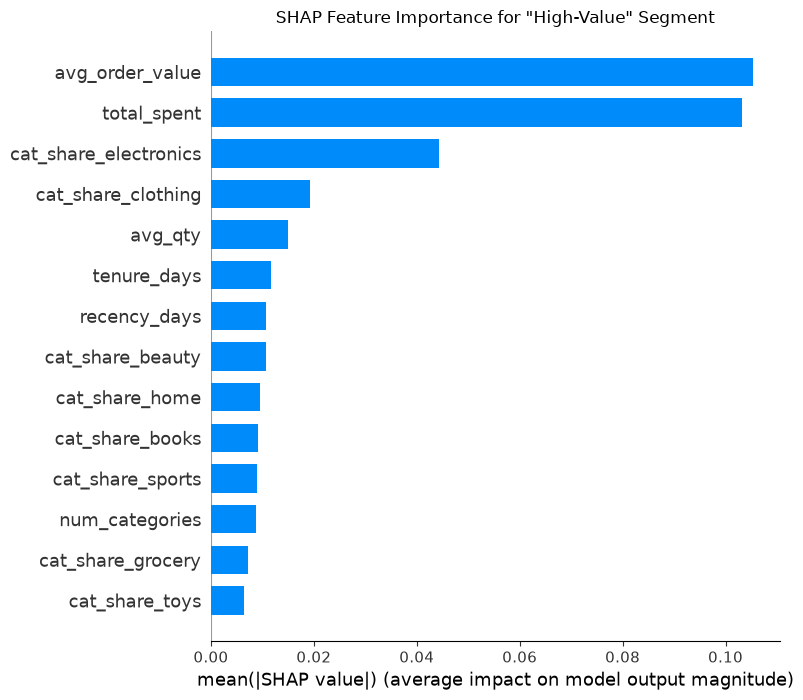

In [23]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

high_value_idx = list(clf.classes_).index('High-Value')
shap.summary_plot(
    shap_values[:, :, high_value_idx], X_test, feature_names=selected_features,
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance for "High-Value" Segment')
plt.tight_layout()
plt.show()


### Limitations

- **Leakage:** the first version of the Step 4b evaluation had a real leakage bug (the held-out purchase was excluded from candidates, forcing Precision@5 to 0). Found and fixed by rebuilding the similarity matrix from a train-only split - see Step 4b.
- **Imbalance:** customer segments are 70% Low / 24% Mid / 7% High-Value; the US and India alone are ~43% of all orders across 15 countries (Step 2). Smaller groups have much less data to learn from or evaluate on.
- **Cold-start:** 34 of 300 test users (11.3%) got *no* recommendation at all, because after holding out their one purchase, they had zero orders left in the training data. Both models are structurally unable to recommend anything for a user (or product) with no purchase history.
- **Overfitting:** the Step 3 segment classifier scores 99.3% accuracy on training data but only 68.3% on the test set - a large gap showing it memorized training users rather than learning a generalizable pattern. The 68.3% test number is the trustworthy one.
- **Data quality (product_id instability):** as found in Step 2/4c, `product_id` doesn't map to a fixed category/price, which caps how good any content-based signal can be, and adds noise to the fairness numbers above.
- **Small sample sizes in the fairness audit:** several country groups have fewer than 15 evaluated users (South Africa has 1), so the fairness metrics above are not statistically reliable on their own.


### Proposed Mitigations

- **Post-processing (cold-start fallback):** for the 11.3% of users with no purchase history to recommend from, fall back to a simple "most popular products" list rather than showing nothing.
- **Reweighting:** when computing similarity, upweight co-purchases from underrepresented countries/segments so the model isn't dominated purely by US/India/Low-Value patterns.
- **Augmentation:** collect more transactions from underrepresented countries (e.g. South Africa, Japan, China each have well under 20 evaluated users here) before drawing firm fairness conclusions - the current audit is data-starved, not necessarily unfair.
- **Threshold/regularization:** reduce the segment classifier's overfitting by limiting tree depth or increasing `min_samples_leaf`, so the train/test accuracy gap shrinks.
- **Fix upstream data quality:** work with whoever owns the data pipeline to give `product_id` a stable category/price, which would directly improve the content-based model and likely overall precision.


## Save Model Artifacts

Persist the full-data (production) similarity matrices for both models, plus the content-based product profile, to `models/`.


In [24]:
import pickle
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

with open(models_dir / 'item_similarity_cf.pkl', 'wb') as f:
    pickle.dump(item_sim_df, f)

with open(models_dir / 'item_similarity_content_based.pkl', 'wb') as f:
    pickle.dump(item_sim_cb, f)

product_profile.to_csv(models_dir / 'product_profile.csv')

print("Saved to models/:")
for p in sorted(models_dir.glob('*')):
    print(' -', p.name)


Saved to models/:
 - .gitkeep
 - item_similarity_cf.pkl
 - item_similarity_content_based.pkl
 - product_profile.csv


## Next Steps
- [ ] Write up findings for the EDA + Feature Engineering report (narrative, outside the notebook)
- [ ] Build two slide decks (technical + business)
- [ ] Set up GitHub repo and push
